In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

from low_rank_rnn.data import generate_perceptual_decision_making_trials
from low_rank_rnn.plotting import (
    COLORS,
    plot_first_perceptual_decision_making_trials,
    set_plot_style,
)

set_plot_style()


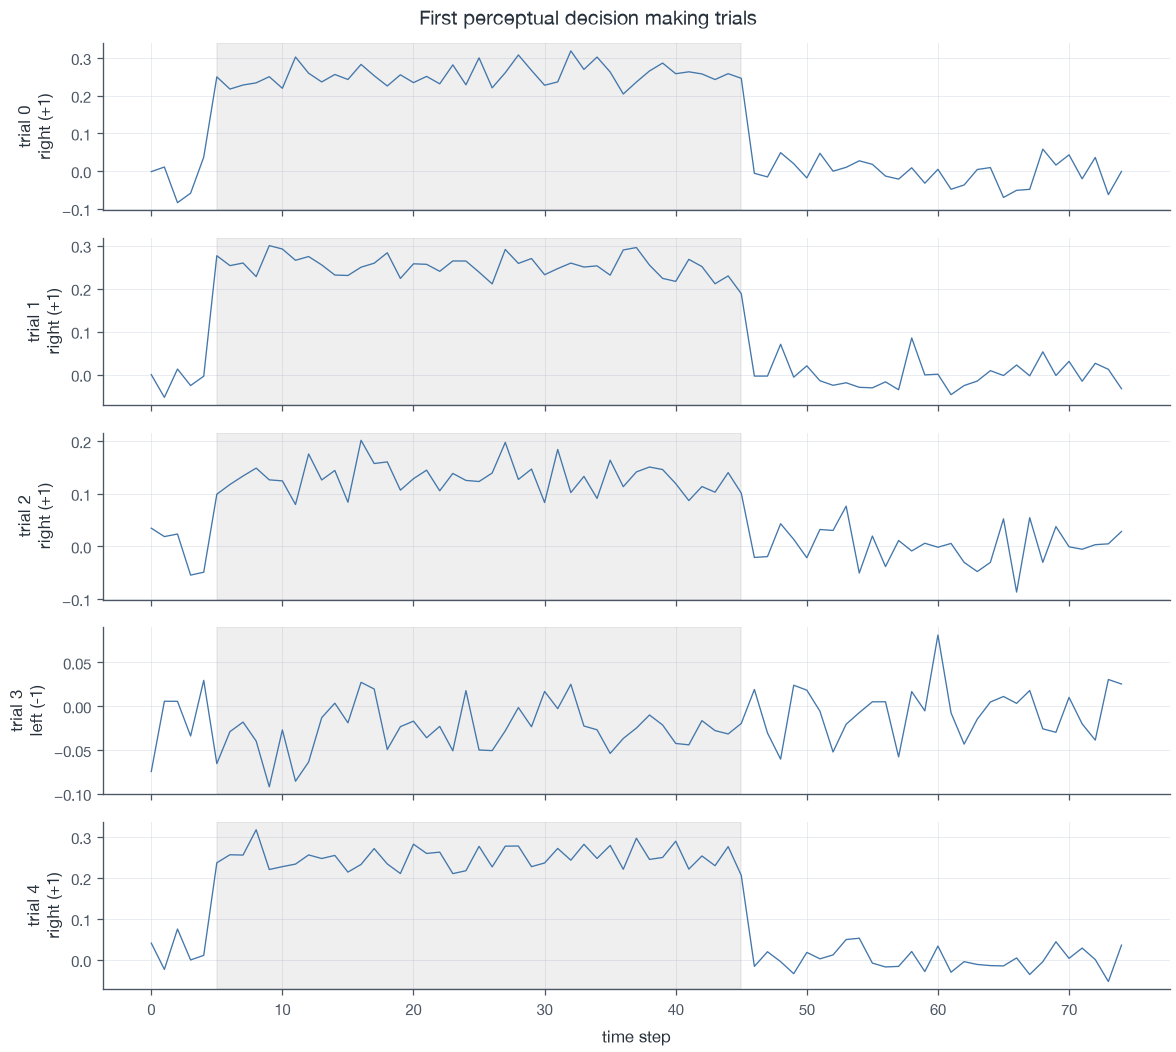

In [20]:
data, labels = generate_perceptual_decision_making_trials(num_trials=20)

fig, axes = plot_first_perceptual_decision_making_trials(
    data,
    labels,
    num_trials=5,
)
plt.show()


In [21]:
tau = 100 # ms
dt = 20 # ms

class LowRankRNN(nn.Module):
    def __init__(self, N: int):
        super().__init__()
        self.N = N

        # Initialize trainable parameters m, n
        self.m = nn.Parameter(torch.randn(N))
        self.n = nn.Parameter(torch.randn(N))
        
        # Initialize fixed parameters w, I
        self.register_buffer("I", torch.randn(N))
        self.register_buffer("w", 4.0 * torch.randn(N))


    def forward(self, u: torch.Tensor):
        batch_size, steps = u.shape
        x = u.new_zeros(batch_size, self.N)

        states, outputs = [], []
        for i in range(steps):
            # store state and output
            z = x @ self.w / self.N
            states.append(x)
            outputs.append(z)

            u_t = u[:, i]
            rates = torch.tanh(x) # (batch_size, N)

            # latent variable
            k = rates @ self.n / self.N # latent variable (batch_size,)
            recurrent = k[:, None] * self.m[None, :]
            external = u_t[:, None] * self.I[None, :]

            # euler step
            x_prime = -x + recurrent + external
            x = x + x_prime * (dt / tau)

        outputs = torch.stack(outputs, dim=1)   
        states = torch.stack(states, dim=1)
        
        return outputs, states

# u, labels = generate_perceptual_decision_making_trials(num_trials=10)
# model = LowRankRNN(N = 100)
# outputs, states = model(torch.tensor(u, dtype=torch.float32))    
# print(outputs.shape, states.shape)


In [29]:
def train_model(model, u, y, *, num_test_trials=160):
    batch_size = 32
    le = 5e-3
    n_epochs = 1000
    decision_timesteps = 15

    # Set up optimizer and dataloader
    optimizer = torch.optim.Adam(model.parameters(), lr=le)
    dataset = torch.utils.data.TensorDataset(u, y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Run over epochs (ex. 1000)
    for epoch in range(n_epochs):
        for batch_u, batch_y in dataloader:
            # Compute MSE loss averaged over batch, for the last 15 timesteps
            outputs, states = model(batch_u)
            decision_outputs = outputs[:, -decision_timesteps:]
            targets = batch_y[:, None].expand_as(decision_outputs)
            loss = torch.nn.functional.mse_loss(decision_outputs, targets)

            # Update model parameters
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")

    test_u, test_labels = generate_perceptual_decision_making_trials(num_trials=num_test_trials)
    test_u = torch.tensor(test_u, dtype=torch.float32)
    test_labels = torch.tensor(test_labels, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        test_outputs, _ = model(test_u)
        decisions = test_outputs[:, -decision_timesteps:].mean(dim=1)
        predictions = torch.sign(decisions)
        accuracy = (predictions == test_labels).float().mean().item()
    model.train()

    print(f"Test accuracy on {num_test_trials} fresh trials: {accuracy:.1%}")
    return accuracy

u, labels = generate_perceptual_decision_making_trials(num_trials=200)    
model = LowRankRNN(N = 128)    
train_model(model, torch.tensor(u, dtype=torch.float32), torch.tensor(labels, dtype=torch.float32))


Epoch 0, Loss: 1.0001342296600342
Epoch 100, Loss: 0.0005242156330496073
Epoch 200, Loss: 0.0001340695598628372
Epoch 300, Loss: 0.00014185647887643427
Epoch 400, Loss: 3.661403025034815e-05
Epoch 500, Loss: 1.4323717550723813e-05
Epoch 600, Loss: 2.730984124355018e-05
Epoch 700, Loss: 1.7840100554167293e-05
Epoch 800, Loss: 1.4952008314139675e-05
Epoch 900, Loss: 1.2566471013997216e-05
Test accuracy on 160 fresh trials: 99.4%


0.9937499761581421

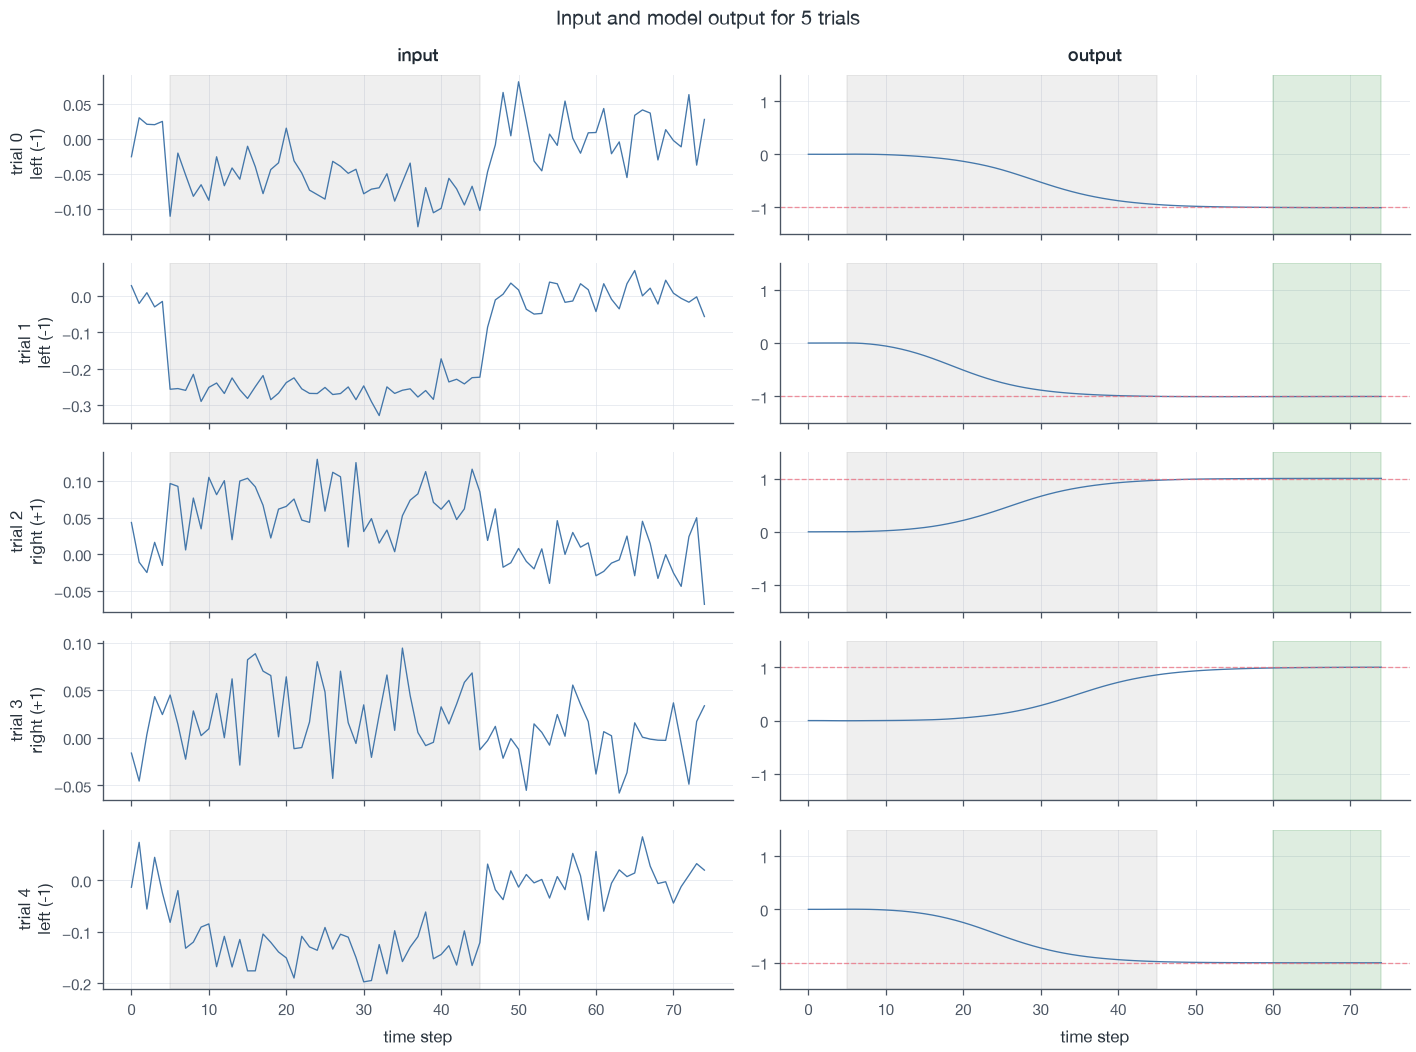

In [31]:
from low_rank_rnn.constants import STIMULUS_WINDOW

num_trials = 5
decision_timesteps = 15
u, labels = generate_perceptual_decision_making_trials(num_trials=num_trials)
outputs, states = model(torch.tensor(u, dtype=torch.float32))

outputs_np = outputs.detach().numpy()
time_steps = np.arange(u.shape[1])
t0, t1 = STIMULUS_WINDOW
decision_start = u.shape[1] - decision_timesteps

fig, axes = plt.subplots(num_trials, 2, figsize=(12, 1.8 * num_trials), sharex="col")
for i in range(num_trials):
    ax_in, ax_out = axes[i]

    ax_in.plot(time_steps, u[i], lw=0.8)
    ax_in.axvspan(t0, t1, color="gray", alpha=0.12)
    direction = "right (+1)" if labels[i] > 0 else "left (-1)"
    ax_in.set_ylabel(f"trial {i}\n{direction}")
    if i == 0:
        ax_in.set_title("input")

    ax_out.plot(time_steps, outputs_np[i], lw=0.8)
    ax_out.axhline(labels[i], color="C1", ls="--", lw=0.8, alpha=0.7)
    ax_out.axvspan(t0, t1, color="gray", alpha=0.12)
    ax_out.axvspan(decision_start, time_steps[-1], color="C2", alpha=0.15)
    ax_out.set_ylim(-1.5, 1.5)
    if i == 0:
        ax_out.set_title("output")

axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")
fig.suptitle("Input and model output for 5 trials")
fig.tight_layout()
plt.show()

# Connectivity Space

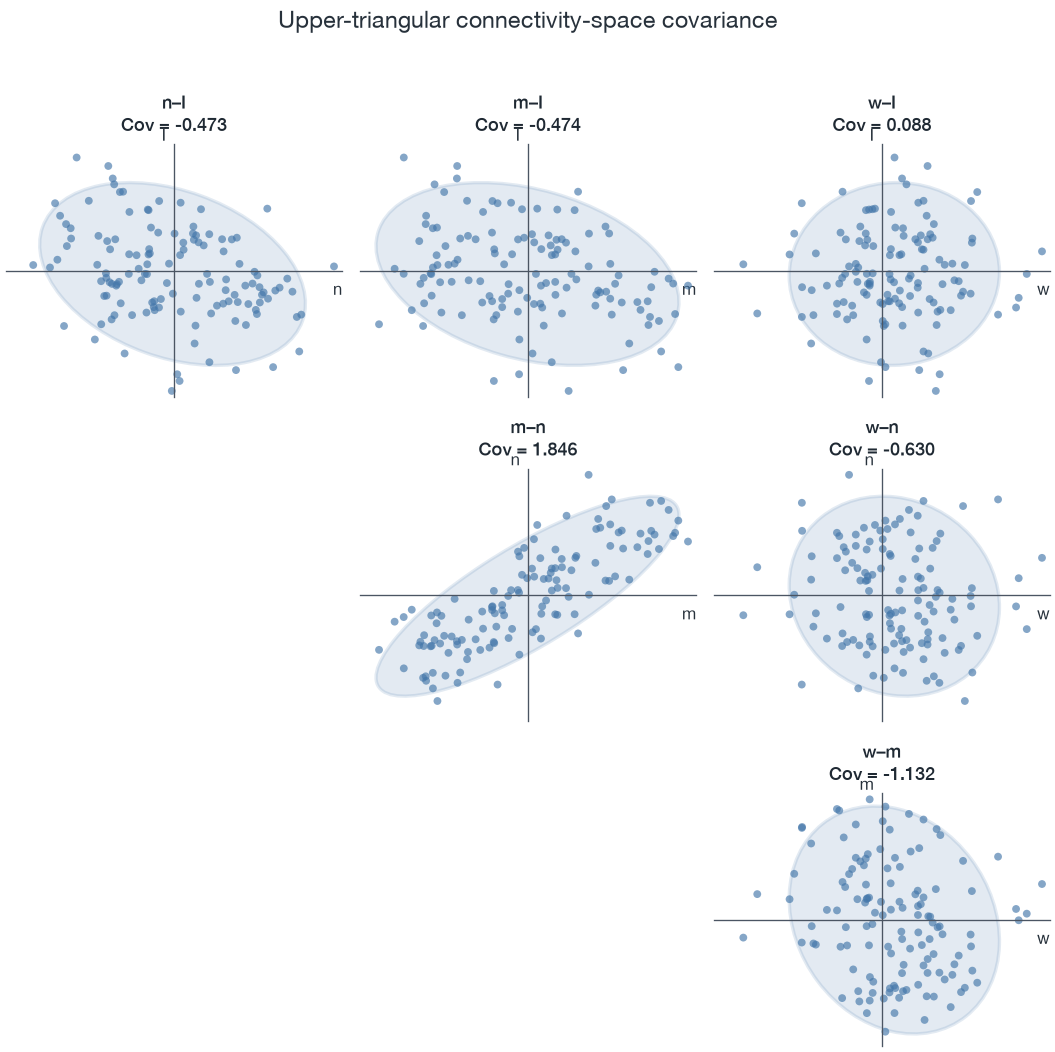

In [32]:
from matplotlib.patches import Ellipse


def add_covariance_ellipse(ax, x, y, n_std=2.0):
    covariance = np.cov(x, y)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(
        (x.mean(), y.mean()),
        width,
        height,
        angle=angle,
        facecolor=COLORS["blue"],
        edgecolor=COLORS["blue"],
        alpha=0.15,
        linewidth=2,
    )
    ax.add_patch(ellipse)
    return covariance[0, 1]


connectivity_vectors = {
    "I": model.I.detach().cpu().numpy(),
    "m": model.m.detach().cpu().numpy(),
    "n": model.n.detach().cpu().numpy(),
    "w": model.w.detach().cpu().numpy(),
}

row_names = ["I", "n", "m"]
column_names = ["n", "m", "w"]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for ax in axes.flat:
    ax.set_visible(False)

for row, y_name in enumerate(row_names):
    for col, x_name in enumerate(column_names):
        if col < row:
            continue

        ax = axes[row, col]
        ax.set_visible(True)

        x = connectivity_vectors[x_name]
        y = connectivity_vectors[y_name]
        ax.scatter(x, y, s=22, alpha=0.65, edgecolors="none")
        cov = add_covariance_ellipse(ax, x, y)

        x_limit = 1.05 * np.max(np.abs(x))
        y_limit = 1.05 * np.max(np.abs(y))
        ax.set_xlim(-x_limit, x_limit)
        ax.set_ylim(-y_limit, y_limit)

        ax.spines["left"].set_position(("data", 0))
        ax.spines["bottom"].set_position(("data", 0))
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        ax.set_xlabel(x_name, loc="right")
        ax.set_ylabel(y_name, loc="top", rotation=0)
        ax.set_title(f"{x_name}–{y_name}\nCov = {cov:.3f}")

fig.suptitle(
    "Upper-triangular connectivity-space covariance",
    fontsize=14,
    x=0.5,
    ha="center",
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


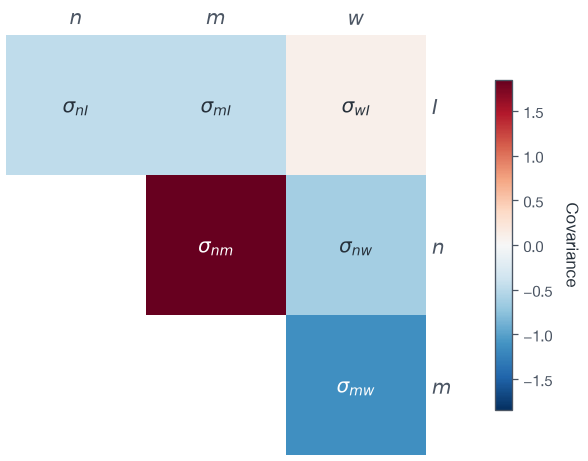

In [33]:
heatmap_names = ["I", "n", "m", "w"]
vector_matrix = np.stack([connectivity_vectors[name] for name in heatmap_names])
covariance_matrix = np.cov(vector_matrix)

# Arrange the six unique cross-covariances as an upper-triangular heat map.
pair_covariances = covariance_matrix[:-1, 1:]
mask = np.tril(np.ones_like(pair_covariances, dtype=bool), k=-1)
visible_covariances = pair_covariances[~mask]
color_limit = np.max(np.abs(visible_covariances))
if np.isclose(color_limit, 0):
    color_limit = 1.0

fig, ax = plt.subplots(figsize=(5.2, 4.0))
image = ax.imshow(
    np.ma.masked_array(pair_covariances, mask=mask),
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)

column_names = heatmap_names[1:]
row_names = heatmap_names[:-1]
ax.set_xticks(range(3), labels=[rf"${name}$" for name in column_names])
ax.set_yticks(range(3), labels=[rf"${name}$" for name in row_names])
ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.tick_params(length=0, labelsize=12)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

for row, row_name in enumerate(row_names):
    for col in range(row, len(column_names)):
        column_name = column_names[col]
        first, second = (
            (column_name, row_name) if row_name == "I" else (row_name, column_name)
        )
        value = pair_covariances[row, col]
        text_color = "white" if abs(value) > 0.55 * color_limit else "#27313B"
        ax.text(
            col,
            row,
            rf"$\sigma_{{{first}{second}}}$",
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
        )

colorbar = fig.colorbar(image, ax=ax, shrink=0.78, pad=0.12)
colorbar.set_label("Covariance", rotation=270, labelpad=18)
fig.tight_layout()
plt.show()

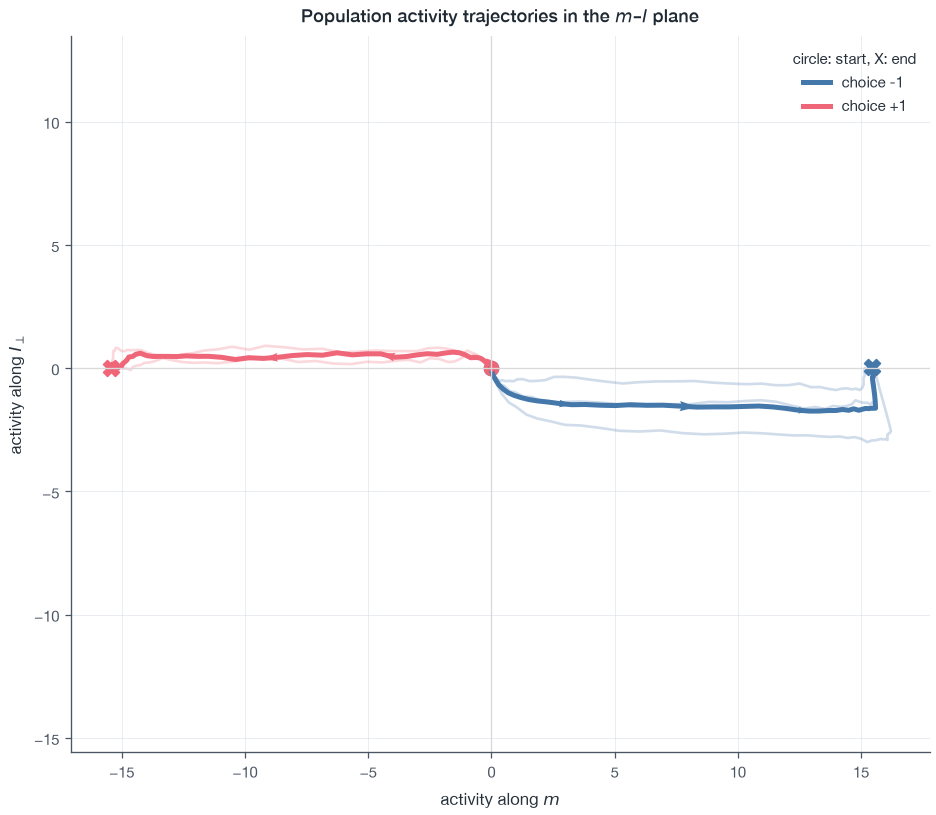

In [34]:
# Project the N-dimensional population activity onto the plane spanned by m and I.
I = model.I.detach()
m = model.m.detach()

q_m = m / torch.linalg.vector_norm(m)
I_orthogonal = I - torch.dot(I, q_m) * q_m
q_I_orthogonal = I_orthogonal / torch.linalg.vector_norm(I_orthogonal)
activity_basis = torch.stack((q_m, q_I_orthogonal), dim=1)  # x: m, y: I_perp

trajectory_2d = (states.detach() @ activity_basis).cpu().numpy()
labels_np = np.asarray(labels)

fig, ax = plt.subplots(figsize=(8, 7))
colors = {-1: COLORS["blue"], 1: COLORS["red"]}

for choice in (-1, 1):
    choice_trajectories = trajectory_2d[labels_np == choice]
    if len(choice_trajectories) == 0:
        continue

    color = colors[choice]
    for trajectory in choice_trajectories:
        ax.plot(trajectory[:, 0], trajectory[:, 1], color=color, alpha=0.25)

    mean_trajectory = choice_trajectories.mean(axis=0)
    ax.plot(
        mean_trajectory[:, 0],
        mean_trajectory[:, 1],
        color=color,
        linewidth=3,
        label=f"choice {choice:+d}",
    )

    # Arrows indicate increasing time along the condition-averaged trajectory.
    arrow_times = np.arange(0, len(mean_trajectory) - 1, 8)
    steps = np.diff(mean_trajectory, axis=0)
    ax.quiver(
        mean_trajectory[arrow_times, 0],
        mean_trajectory[arrow_times, 1],
        steps[arrow_times, 0],
        steps[arrow_times, 1],
        color=color,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.004,
    )

    ax.scatter(*mean_trajectory[0], color=color, marker="o", s=70)
    ax.scatter(*mean_trajectory[-1], color=color, marker="X", s=90)

ax.axhline(0, color="0.85", linewidth=0.8)
ax.axvline(0, color="0.85", linewidth=0.8)
ax.set_xlabel(r"activity along $m$")
ax.set_ylabel(r"activity along $I_\perp$")
ax.set_title("Population activity trajectories in the $m$–$I$ plane")
ax.legend(title="circle: start, X: end")
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
plt.show()